### Dataset 

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Apple SD Gothic Neo'

In [91]:
cols = ["engine_id", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
train1 = pd.read_csv("../data/raw/train_FD001.txt", sep=r"\s+", header=None, names=cols)
train2 = pd.read_csv("../data/raw/train_FD002.txt", sep=r"\s+", header=None, names=cols)
train3 = pd.read_csv("../data/raw/train_FD003.txt", sep=r"\s+", header=None, names=cols)
train4 = pd.read_csv("../data/raw/train_FD004.txt", sep=r"\s+", header=None, names=cols)

### train데이터에서의 각 열의 정보   
> 1열 : ID(총 100개의 센서)   
> 2열 : Cycle수   
> 3~5열 : 작동 조건(비행 고도, 스로틀 리졸버 각도 등)   
> 6~21열 : 센서 측정값(온도, 압력, 속도, 비율) 



In [115]:
train1.head(10).transpose() 

,0,1,2,3,4,5,6,7,8,9
engine_id,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
cycle,1.0000,2.0000,3.0000,4.0000,5.0000,6.0000,7.0000,8.0000,9.0000,10.0000
op1,-0.0007,0.0019,-0.0043,0.0007,-0.0019,-0.0043,0.0010,-0.0034,0.0008,-0.0033
op2,-0.0004,-0.0003,0.0003,0.0000,-0.0002,-0.0001,0.0001,0.0003,0.0001,0.0001
op3,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000
s1,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700
s2,641.8200,642.1500,642.3500,642.3500,642.3700,642.1000,642.4800,642.5600,642.1200,641.7100
s3,1589.7000,1591.8200,1587.9900,1582.7900,1582.8500,1584.4700,1592.3200,1582.9600,1590.9800,1591.2400
s4,1400.6000,1403.1400,1404.2000,1401.8700,1406.2200,1398.3700,1397.7700,1400.9700,1394.8000,1400.4600
s5,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200


- cycle열의 min, max값을 확인했을 때 최소 수명 1회, 최대 수명 362회인 것을 확인

### 표준편차가 0인 센서들 확인 - 변동이 없는 센서들은 결과에 영향을 주지 않기 떄문에 제외
**FD001** : op3,s1,s10,s18,s19 <br>
**FD002** : x<br>
**FD003** : op3,s1,s18,s19<br>
**FD004** : x<br>

In [116]:
train1_des = train1.describe()
train2_des = train2.describe()
train3_des = train3.describe()
train4_des = train4.describe()

In [133]:
train4_des.loc['std']

engine_id     71.995350
cycle         89.783389
op1           14.780722
op2            0.310703
op3           14.251954
s1            26.436832
s2            37.342647
s3           106.167598
s4           119.327591
s5             3.622872
s6             5.444017
s7           146.880210
s8           145.348243
s9           336.927547
s10            0.127681
s11            3.243492
s12          138.479109
s13          128.197859
s14           85.670543
s15            0.750374
s16            0.004685
s17           27.808283
s18          145.472491
s19            5.369424
s20            9.936396
s21            5.962697
Name: std, dtype: float64

### 엔진별 사이클 수명 분포
아이디별로 max값 만을 보아야함

In [96]:
life_cycle = train1.groupby('engine_id')['cycle'].max()

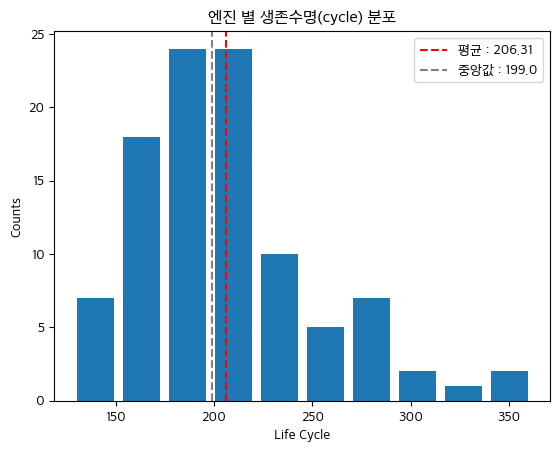

In [97]:
plt.hist(life_cycle,rwidth=0.8)
plt.xlabel('Life Cycle')
plt.ylabel('Counts')
plt.title('엔진 별 생존수명(cycle) 분포')
plt.axvline(life_cycle.mean(),linestyle='--',color='red',label=f'평균 : {life_cycle.mean()}')
plt.axvline(life_cycle.median(),linestyle='--',color='gray',label=f'중앙값 : {life_cycle.median()}')
plt.legend()

In [67]:
print(life_cycle.skew()) #왜도
print(life_cycle.kurtosis()) #첨도

1.0314712489551392
1.2341217576534755


왜도 = 1.03   
첨도 = 1.23

왜도와 첨도 모두 1점. 적당히 치우친 분포이다.

### 센서 통계

In [98]:
train_sensors_name = train1.columns[5:]

In [99]:
train1[train_sensors_name].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
s1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200
s6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
s7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
s8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
s9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
s10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


### 센서 별 열화 경향 

1번엔진 선택
1번엔진에서 op3,s1,s10,s18,s19는 표준편차 0이므로 제외

In [148]:
train1_engine1_sensor_column = [ 's1', 's2', 's3', 's4', 's5',
       's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16',
       's17', 's18', 's19', 's20', 's21']

In [149]:
train1_engine1 = train1[train1['engine_id']==1]

/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn/T/ipykernel_8734/3993529811.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


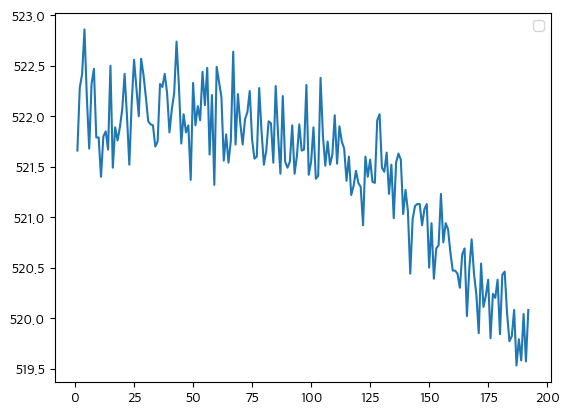

In [154]:
plt.plot(train1_engine1['cycle'],train1_engine1['s12'])
plt.legend()